# Where can I find pretrained models?

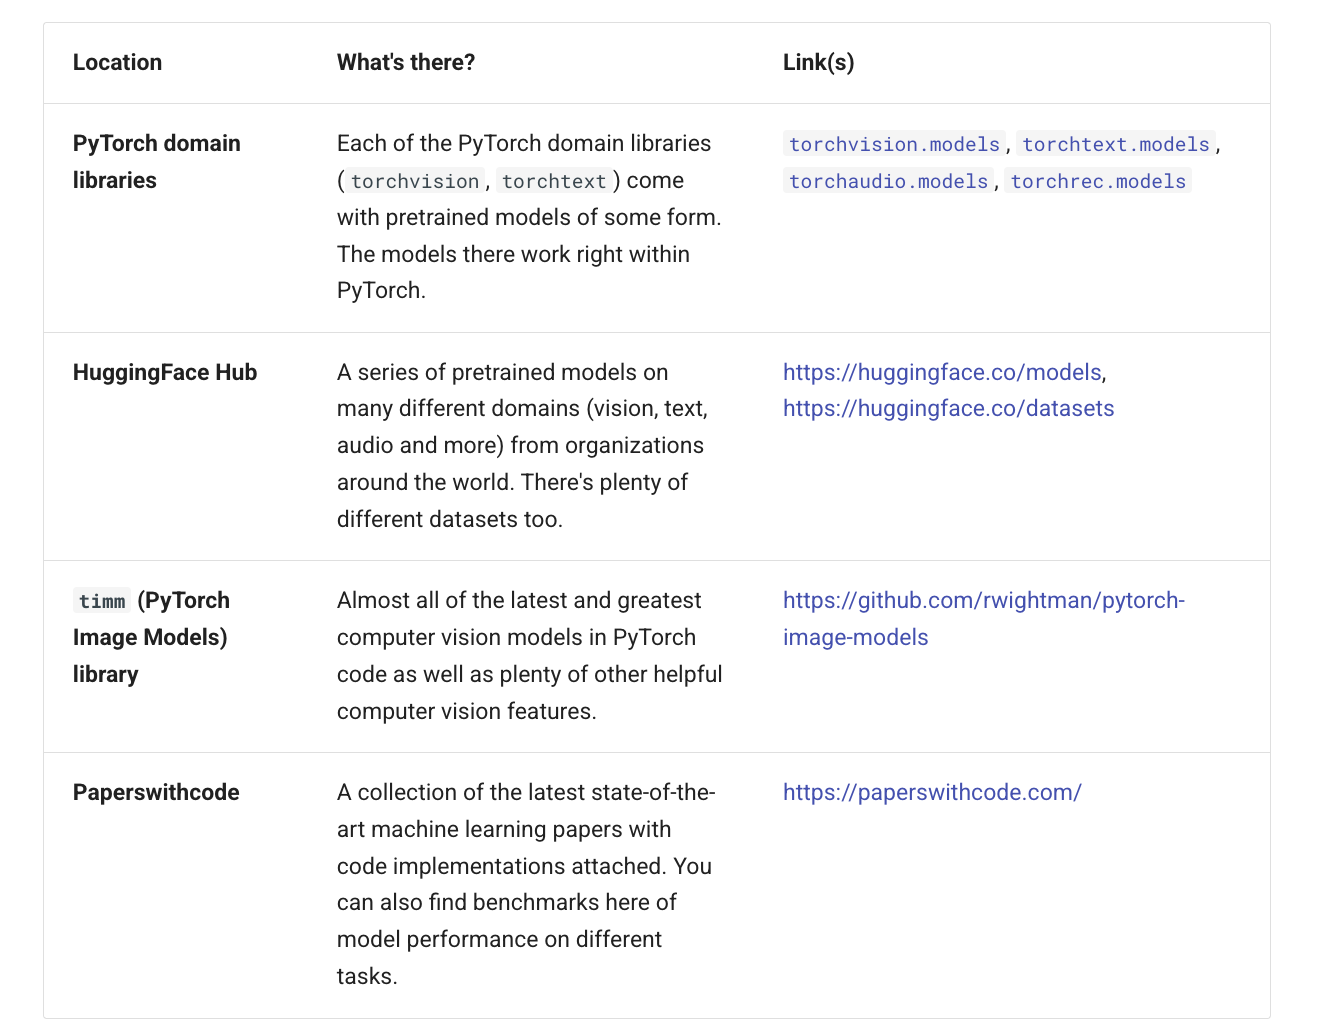

In [2]:
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo
    from torchinfo import summary

You should consider upgrading via the '/Users/dhurbabaral/Documents/pytorch/learnpytorch/pytorch-venv/bin/python3 -m pip install --upgrade pip' command.


In [13]:
import sys, os
repo_root = "/Users/dhurbabaral/Documents/pytorch/learnpytorch"
if repo_root not in sys.path:
    sys.path.append(repo_root)

from PyTorch_Going_Modular.going_modular import data_setup, model_builder, engine, utils

/Users/dhurbabaral/Documents/pytorch/learnpytorch/pytorch-venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# 0. Get Data

In [19]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

/Users/dhurbabaral/Documents/pytorch/learnpytorch/pytorch-venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [20]:
# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

# 1. Create Datasets and Dataloaders